# Data Collection
The aim of this notebook is to load, inspect and document the raw disaster messages dataset as well as identify potential data quality issues that will be addressed later on.

#### Next notebook: [Data provisioning](02_data_provisioning.ipynb)

#### Data source
The data used in this project comes from the publicly available disaster response dataset originally released by "Figure Eight"/"Appen" and later mirrored on different platforms (GitHub). It contains short text messages sent during real disasters such as an earthquake in Haiti, floods in Pakistan, superstorm Sandy in the U.S.A., etc. The messages have been classified in 36 categories and the sensitive information has been completely removed. Currently, "Appen" does no longer provide the original download page, but the original dataset has been mirrored under a public-domain licence.

*Find raw dataset:* [Disaster response dataset](https://github.com/Bhardwaj-Saurabh/Project-Disaster-Response-pipeline.git)

#### Files
The dataset is provided in 2 main files:
 - `disaster_messages.csv` - provides the raw text messages
 - `disaster_categories.csv` - provides the label information for each message in one semicolon-separated string

#### Format & Structure
Both files are stored in a CSV format (comma-separated values).

**Data dictionary**: [Disaster dataset dictionary](../docs/Data%20dictionary.md)

#### Data Quality Considerations
 - *Missing values* - many NaN values in the *original* column because some messages were originally written in English and therefore does not provide "original language" version
  - *Duplicate samples* - 68 duplicate values detected in both files; after initial inspection it was concluded that they are due to messages being labeled multiple times by different people
  - *Label representation* - all category labels per message are stored in a single text field, separated by semicolons
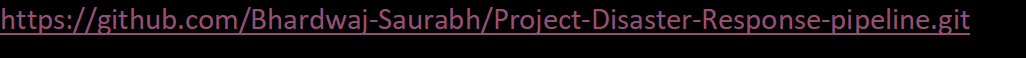

## Load raw data
### Messages
In this step, I load the raw message file from the disaster dataset and inspect its structure. The file `disaster_messages.csv` contains one row per message. Each row has:
  - *id* - numeric identifier of the message
  - *message* - the text content of the message (either the original text if in English or the translation)
  - *original* - the original text in the source language
  - *genre* - source of the message("direct", "social", "news")

 The code below reads the raw dataset and loads the shape, basic structure and the first few rows of the file.

In [1]:
import pandas as pd

df_messages = pd.read_csv("../data/raw/original/disaster_messages.csv")
print(df_messages.shape)
print(df_messages.info())

(26248, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26248 entries, 0 to 26247
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        26248 non-null  int64 
 1   message   26248 non-null  object
 2   original  10184 non-null  object
 3   genre     26248 non-null  object
dtypes: int64(1), object(3)
memory usage: 820.4+ KB
None


In [2]:
df_messages.head()

,id,message,original,genre
0,2,Weather update - a cold front from Cuba that c...,Un front froid se retrouve sur Cuba ce matin. ...,direct
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ...",direct
3,9,UN reports Leogane 80-90 destroyed. Only Hospi...,UN reports Leogane 80-90 destroyed. Only Hospi...,direct
4,12,"says: west side of Haiti, rest of the country ...",facade ouest d Haiti et le reste du pays aujou...,direct


The output above shows that the `disaster_messages.csv` consists of 26248 rows and 4 columns. All columns are being stored in a appropriate data type - ids as integers and all others as text fields. The *original* column contains many missing values, which is expected as most of the messages are already in English and do not need translation.

### Categories
In this section, I load the raw `disaster_categories.csv` and inspect its structure using the same functions mentioned above - **shape**, **info** and **head**. This file provides 36 binary labels for each message:
 - *id* - numeric identifier of the messages
 - *categories* - single text field that combines all category labels separated by a semicolon

Each label is paired with a binary value, where:
 - 0 - used when the category does not apply to the message
 - 1 - used when the category applies to the message

It is important to note that one message could activate multiple labels, which is why this is a multi-label classification problem.

In [3]:
df_categories = pd.read_csv("../data/raw/original/disaster_categories.csv")
print(df_categories.shape)
print(df_categories.info())

(26248, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26248 entries, 0 to 26247
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          26248 non-null  int64 
 1   categories  26248 non-null  object
dtypes: int64(1), object(1)
memory usage: 410.3+ KB
None


In [4]:
df_categories.head()

,id,categories
0,2,related-1;request-0;offer-0;aid_related-0;medi...
1,7,related-1;request-0;offer-0;aid_related-1;medi...
2,8,related-1;request-0;offer-0;aid_related-0;medi...
3,9,related-1;request-1;offer-0;aid_related-1;medi...
4,12,related-1;request-0;offer-0;aid_related-0;medi...


The output above confirms that the two columns are stored with appropriate data type for the current version. In the `02_data_provisioning` notebook the categories will be split into separate binary columns to make data easier to analyse and work with.

## Check for duplicate Ids
To verify that the ids uniquely identify each message and its labels, I calculate how many ids appear more than ones in each file. This step is crucial as it ensures the data quality and prevents further potential errors.

In [5]:
dup_messages = df_messages["id"].duplicated().sum()
dup_categories = df_categories["id"].duplicated().sum()

print("Detected duplicate ids in df_message:", dup_messages)
print("Detected duplicate ids in df_categories:", dup_categories)

Detected duplicate ids in df_message: 68
Detected duplicate ids in df_categories: 68


The output above shows that there are 68 duplicate ids per file. The original documentation does not provide an exact explanation to why some samples could appear multiple times. However, it is mentioned that the messages were annotated by a combination of paid and volunteer individuals, which could mean that one message was annotated multiple times by different people, leading to duplicates.

### Inspect Messages Dataset
After detecting the duplicate ids, I will look more into those rows to understand whether the samples are repeating themselves or there are slight differences. In this section, I select the rows with duplicate ids and count how many different values each column has.

In [6]:
dup_msg = df_messages[df_messages["id"].duplicated(keep=False)].sort_values("id")
dup_msg_summary = dup_msg.groupby("id").nunique()
print(dup_msg_summary["message"].value_counts())
print(dup_msg_summary["original"].value_counts())
print(dup_msg_summary["genre"].value_counts())

message
1    67
Name: count, dtype: int64
original
0    36
1    31
Name: count, dtype: int64
genre
1    67
Name: count, dtype: int64


The *message* and *genre* column indicate complete duplication. In the *original* column, we can see either 0 - represents NaN values, or 1 - one unique non-missing value. These results confirm that detected duplicates in the `disaster_messages.csv` are repeated copies of the same sample. Therefore, I will keep one sample per duplicate id and drop the remaining once:

In [7]:
df_msg = df_messages.drop_duplicates(subset="id", keep="first")
print(df_msg.shape)
print(df_msg.info())

(26180, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 26180 entries, 0 to 26247
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        26180 non-null  int64 
 1   message   26180 non-null  object
 2   original  10153 non-null  object
 3   genre     26180 non-null  object
dtypes: int64(1), object(3)
memory usage: 1022.7+ KB
None


In [8]:
df_msg.to_csv("../data/raw/removed_duplicates/disaster_messages.csv", index=False)

After removing the duplicate samples, the `disaster_messages.csv` consists of 26180 rows and 4 columns. To ensure traceability and reproducibility, I save the cleaned version of the file in the `removed_duplicates` folder.

### Inspect Categories Dataset
After deduplicating the raw messages file, I will similarly inspect the `disaster_categories.csv` to understand how the labeled information differs between rows.

In [9]:
dup_cat = df_categories[df_categories["id"].duplicated(keep=False)].sort_values("id")
dup_cat_summary = dup_cat.groupby("id").nunique()
print(dup_cat_summary["categories"].value_counts())

categories
2    36
1    31
Name: count, dtype: int64


The output table shows that some sampled with duplicate ids share the same categories string (1), while others (2) have two different versions for the same message. This confirms the speculations that some messages were likely labeled multiple times. To address this problem, I will first separate the *category* strings into separate columns and then aggregate the labels, so any category that was marked as present in at least one row remains marked as present in the final label vector.